In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [3]:
average_sentiment_reddit_daily = pd.read_csv('average_sentiment_reddit_daily.csv')
average_sentiment_reviews_daily = pd.read_csv('average_sentiment_reviews_daily.csv')
player_counts_full_year = pd.read_csv('player_counts_full_year.csv')
twitch_counts_full_year = pd.read_csv('twitch_counts_full_year.csv')
game_names = pd.read_csv('game_names_after_sentiment_analysis.csv')

In [4]:
name_to_appid = dict(zip(game_names['name'], game_names['appid']))
player_counts_full_year.rename(columns=name_to_appid, inplace=True)

In [5]:
for col in player_counts_full_year.columns[1:]:
    if col not in game_names['appid'].values:
        player_counts_full_year.drop(columns=col, inplace=True)

In [6]:
twitch_counts_full_year.drop(columns = ['3164500.1', '2138720.1'], inplace=True)
for col in twitch_counts_full_year.columns[2:]:
    if int(col) not in game_names['appid'].values:
        twitch_counts_full_year.drop(columns=col, inplace=True)

In [7]:
average_sentiment_reddit_daily['date'] = pd.to_datetime(average_sentiment_reddit_daily['date'])
average_sentiment_reviews_daily['date'] = pd.to_datetime(average_sentiment_reviews_daily['date'])
player_counts_full_year['DateTime'] = pd.to_datetime(player_counts_full_year['DateTime'])
twitch_counts_full_year['DateTime'] = pd.to_datetime(twitch_counts_full_year['DateTime'])

In [8]:
average_sentiment_reddit_daily.set_index('date', inplace=True)
average_sentiment_reviews_daily.set_index('date', inplace=True)
player_counts_full_year.set_index('DateTime', inplace=True)
twitch_counts_full_year.set_index('DateTime', inplace=True)

In [9]:
reddit_weekly = average_sentiment_reddit_daily.resample('W').mean()
reviews_weekly = average_sentiment_reviews_daily.resample('W').mean()
player_counts_weekly = player_counts_full_year.resample('W').mean()
twitch_counts_weekly = twitch_counts_full_year.resample('W').mean()

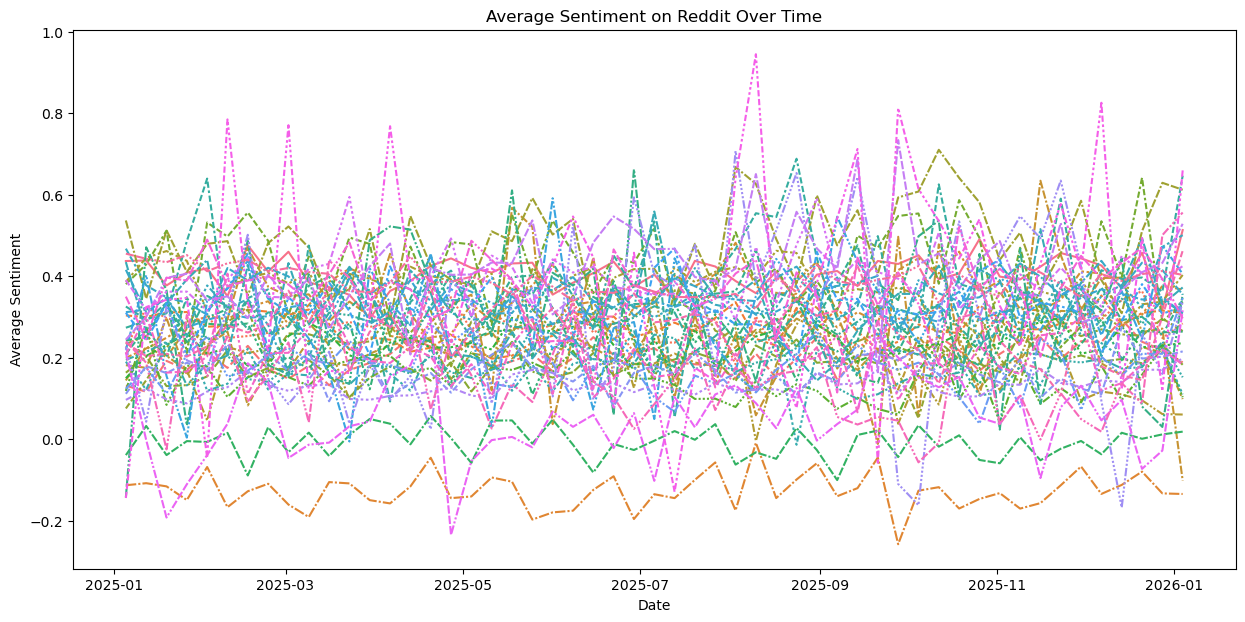

<module 'seaborn' from 'c:\\Users\\magda\\mambaforge\\envs\\magisterka\\Lib\\site-packages\\seaborn\\__init__.py'>

In [10]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=reddit_weekly[reddit_weekly.columns[1:]], legend=False)
plt.title('Average Sentiment on Reddit Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.show()
sns

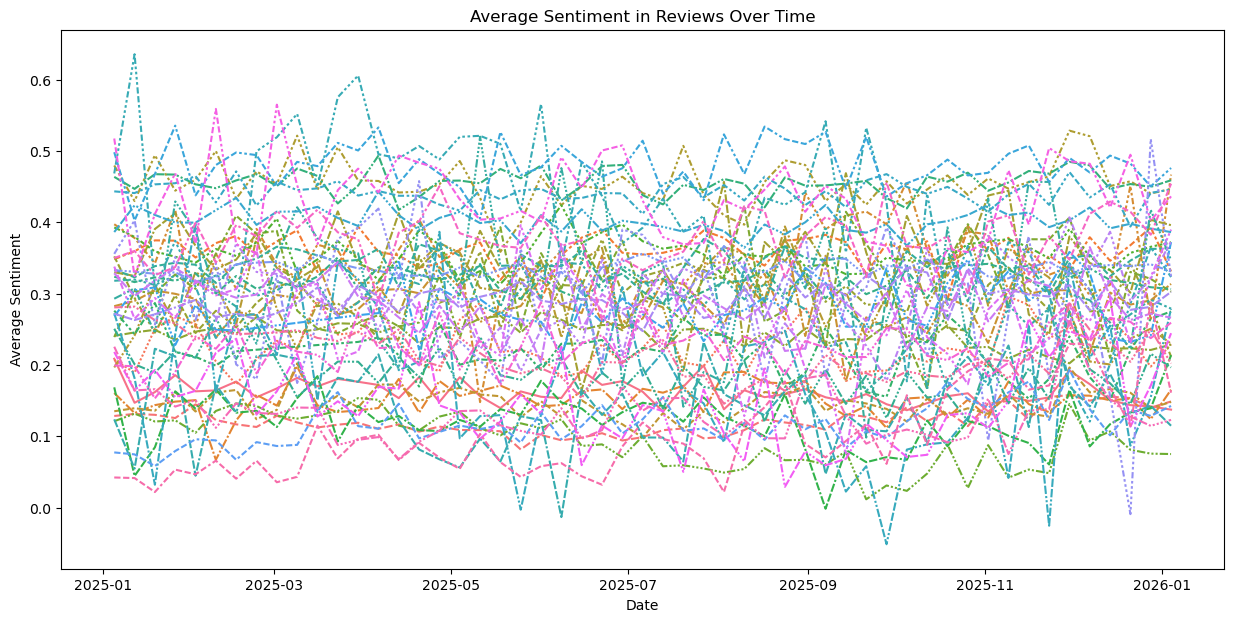

In [11]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=reviews_weekly[reviews_weekly.columns[1:]], legend=False)
plt.title('Average Sentiment in Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.show()

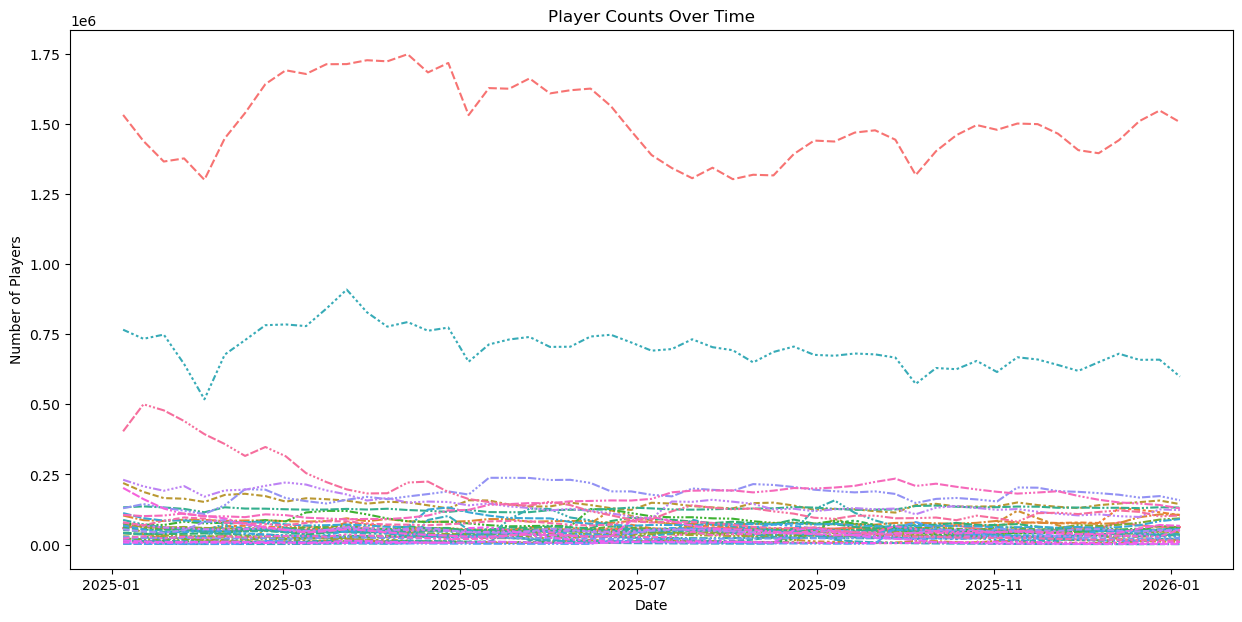

In [12]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=player_counts_weekly[player_counts_weekly.columns[1:]], legend=False)
plt.title('Player Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Players')
plt.show()

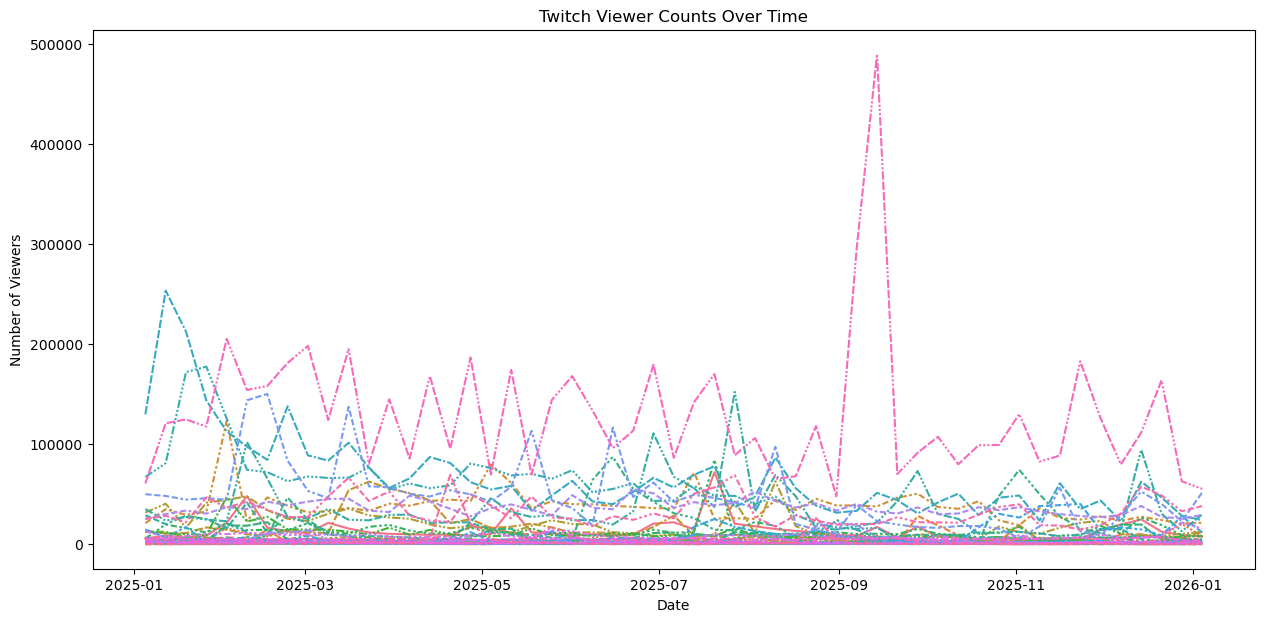

In [13]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=twitch_counts_weekly[twitch_counts_weekly.columns[1:]], legend=False)
plt.title('Twitch Viewer Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Viewers')
plt.show()

In [14]:
player_counts_full_year.isna().sum()

570        0
730        0
578080     0
2767030    0
1203220    0
1623730    0
2507950    0
221100     0
261550     0
438100     0
489830     0
1158310    0
1517290    0
1604030    0
289070     0
322330     0
1091500    0
1245620    0
242760     0
322170     0
367520     0
394360     0
236390     0
381210     0
552990     0
1973530    0
359550     0
431960     0
899770     0
1086940    0
230410     0
238960     0
553850     0
252490     0
1172470    0
440        0
275850     0
294100     0
1085660    0
1145350    0
1174180    0
2669320    0
dtype: int64

In [15]:
twitch_counts_full_year.isna().sum()

Unnamed: 0    0
1085660       0
1086940       0
1091500       0
1145350       0
1158310       0
1172470       0
1174180       0
1203220       0
1245620       0
1449850       0
1517290       0
1604030       0
1623730       0
1973530       0
221100        0
230410        0
236390        0
238960        0
242760        0
2507950       0
252490        0
261550        0
2669320       0
275850        0
2767030       0
289070        0
294100        0
322170        0
322330        0
359550        0
367520        0
381210        0
394360        0
438100        0
440           0
489830        0
552990        0
553850        0
570           0
578080        0
899770        0
dtype: int64

In [16]:
player_counts_full_year.columns = player_counts_full_year.columns.astype(str)
twitch_counts_full_year.columns = twitch_counts_full_year.columns.astype(str)
average_sentiment_reddit_daily.columns = average_sentiment_reddit_daily.columns.astype(str)
average_sentiment_reviews_daily.columns = average_sentiment_reviews_daily.columns.astype(str)

In [ ]:
#---------------------------------------------------------------------------------------------------------

In [22]:
game_id = '570'
# 1. Stitch your raw data toge
# ther as before
df_game = pd.DataFrame({
    'player_counts': player_counts_full_year[game_id],
    'twitch_counts': twitch_counts_full_year[game_id],
    'reddit_sentiment': average_sentiment_reddit_daily[game_id],
    'reviews_sentiment': average_sentiment_reviews_daily[game_id] # or your review table
})

# 2. Take the daily difference to make it stationary
df_diff = df_game.diff().dropna()

# 3. Apply Z-score Normalization to the differenced data
df_scaled = (df_diff - df_diff.mean()) / df_diff.std()

# 4. Feed df_scaled into your VAR model
model = VAR(df_scaled)
lag_order_results = model.select_order(maxlags=14)
optimal_lag = lag_order_results.selected_orders['aic']

# 5. Fit the model and print your results!
results = model.fit(optimal_lag)
print(results.summary())


   Summary of Regression Results   
Model:                          VAR
Method:                         OLS
Date:           pon., 18, maj, 2026
Time:                      23:36:28
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   0.280057
Nobs:                     350.000    HQIC:                  -1.23278
Log likelihood:          -1367.72    FPE:                   0.108457
AIC:                     -2.23311    Det(Omega_mle):       0.0593131
--------------------------------------------------------------------
Results for equation player_counts
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.005071         0.029064            0.174           0.861
L1.player_counts             -0.405027         0.055474           -7.301           0.000
L1.twitch_count

c:\Users\magda\mambaforge\envs\magisterka\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [25]:
import warnings
import pandas as pd
from statsmodels.tsa.api import VAR

# Suppress standard execution warnings for a cleaner output window
warnings.filterwarnings("ignore")

# Master lists to hold results and track any error games
thesis_results = []
failed_games = []

# Get all unique game IDs from your columns (assumes 'date' is skipped)
all_game_ids = [
    col for col in player_counts_full_year.columns if col != "date"
]

print(f"Starting VAR processing loop for {len(all_game_ids)} games...\n")

for game_id in all_game_ids:
    try:
        # 1. Align and stitch all 4 dataframes for the current game
        df_game = pd.DataFrame(
            {
                "player_counts": player_counts_full_year[game_id],
                "twitch_counts": twitch_counts_full_year[game_id],
                "reddit_sentiment": average_sentiment_reddit_daily[game_id],
                "reviews_sentiment": average_sentiment_reviews_daily[game_id]
            }
        ).dropna()

        # Skip games with insufficient continuous daily observations
        if len(df_game) < 45:
            continue

        # 2. Convert to stationarity via first-differencing
        df_diff = df_game.diff().dropna()

        # 3. Apply Z-score Standardization (Normalization)
        df_scaled = (df_diff - df_diff.mean()) / df_diff.std()

        # 4. Initialize VAR and optimize lag order via AIC (up to 2 weeks back)
        model = VAR(df_scaled)
        lag_order_results = model.select_order(maxlags=14)
        optimal_lag = lag_order_results.selected_orders["aic"]

        # Safeguard against zero-lag selections
        if optimal_lag == 0 or optimal_lag is None:
            optimal_lag = 7

        # 5. Fit the standardized VAR model
        results = model.fit(optimal_lag)

        # 6. Extract statistically significant coefficients (p < 0.05)
        for to_var in results.names:  # The dependent variable equation
            for from_var in results.names:  # The lag predictor variable
                for lag in range(1, optimal_lag + 1):
                    lag_str = f"L{lag}.{from_var}"

                    # Safely grab the corresponding p-value and coefficient
                    p_val = results.pvalues[to_var][lag_str]
                    coef = results.params[to_var][lag_str]

                    # Filter for significance
                    if p_val < 0.05:
                        thesis_results.append(
                            {
                                "Game_ID": game_id,
                                "Predictor_Variable": from_var,
                                "Target_Variable": to_var,
                                "Lag_Days": lag,
                                "Standardized_Coef": round(coef, 4),
                                "P_Value": round(p_val, 4),
                            }
                        )

    except Exception as e:
        failed_games.append({"Game_ID": game_id, "Error_Message": str(e)})

# Convert lists into production-ready Pandas dataframes
df_var_master = pd.DataFrame(thesis_results)
df_var_errors = pd.DataFrame(failed_games)

print("--- Loop Processing Complete ---")
print(
    f"Successfully parsed: {len(all_game_ids) - len(df_var_errors)} games."
)
print(f"Total significant relationships found: {len(df_var_master)}")
if not df_var_errors.empty:
    print(f"Games with structural errors: {len(df_var_errors)}")

Starting VAR processing loop for 42 games...

--- Loop Processing Complete ---
Successfully parsed: 39 games.
Total significant relationships found: 1599
Games with structural errors: 3


In [26]:
# Filter out variables predicting themselves to focus purely on cross-influences
cross_influences = df_var_master[df_var_master['Predictor_Variable'] != df_var_master['Target_Variable']]

# Count occurrences of specific paths
print(cross_influences.groupby(['Predictor_Variable', 'Target_Variable']).size().sort_values(ascending=False))

Predictor_Variable  Target_Variable  
twitch_counts       player_counts        108
player_counts       twitch_counts         67
reddit_sentiment    player_counts         30
player_counts       reviews_sentiment     27
reviews_sentiment   twitch_counts         26
                    player_counts         22
twitch_counts       reviews_sentiment     20
reddit_sentiment    reviews_sentiment     19
twitch_counts       reddit_sentiment      15
reviews_sentiment   reddit_sentiment      15
reddit_sentiment    twitch_counts         14
player_counts       reddit_sentiment      13
dtype: int64


In [27]:
review_to_players = df_var_master[(df_var_master['Predictor_Variable'] == 'reviews_sentiment') & 
                                  (df_var_master['Target_Variable'] == 'player_counts')]

print("Average days for Steam Reviews to impact player numbers:", review_to_players['Lag_Days'].mean())

Average days for Steam Reviews to impact player numbers: 6.2727272727272725
